# Notebook 06 — Evaluacion y comparacion de variantes del Informer

Este notebook cierra la **Actividad 3**. Toma la configuracion de hiperparametros seleccionada en el Notebook 05 (`hp_best.pkl`) y, con ella fija, entrena el mismo modelo Informer en las **3 variantes x 3 horizontes** (9 modelos comparables en igualdad de condiciones). Luego evalua el desempeno sobre el conjunto de prueba en **unidades fisicas (W/m2)**, lo compara contra una **linea base de persistencia** y genera las figuras para el documento.

**Variantes (grupos de variables):** V1 autorregresivo, V2 con meteorologia de NASA POWER y V3 completo (con irradiancia satelital). **Horizontes:** 1 h, 3 h y 6 h.

**Decisiones de evaluacion:**
- Las predicciones se desnormalizan a W/m2 con `scaler_rs` y se recortan a valores no negativos (la irradiancia no puede ser negativa).
- Se reportan metricas **globales** y **diurnas**. Como RS = 0 de noche es trivial de predecir, las metricas globales tienden a verse optimistas; las metricas diurnas (sobre puntos con irradiancia observada por encima de un umbral) reflejan el desempeno real y son las que conviene destacar en el documento.
- La **persistencia** (repetir el ultimo valor observado) es la referencia minima: el *skill score* mide cuanto mejora el Informer sobre ella.

**Salidas:** `resultados/metricas_variantes.csv`, `resultados/historias.pkl`, y las figuras de desempeno, curvas de aprendizaje, prediccion frente a observacion y dispersion en `figuras/`.

In [3]:
# 1. Configuracion del entorno
!pip install torch numpy pandas matplotlib scikit-learn --quiet

import os, sys, gc, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = torch.cuda.is_available()

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# 'piloto' valida el flujo completo en pocos minutos; 'completo' es la corrida definitiva.
# Los checkpoints incluyen el MODO en el nombre, de modo que piloto y completo no se mezclan.
MODO = 'completo'

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('AMP     :', USE_AMP)
print('MODO    :', MODO)

PyTorch : 2.11.0+cu128
Device  : cuda
AMP     : True
MODO    : completo


In [4]:
# 2. Montaje de Google Drive y resolucion de rutas
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive ya montado.')

res = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'config_fe.pkl'],
    capture_output=True, text=True, timeout=240
)
rutas = [r for r in res.stdout.strip().split('\n') if r]
if not rutas:
    raise FileNotFoundError('No se encontro config_fe.pkl. Ejecute primero el Notebook 04.')

RUTA_ARRAYS = os.path.dirname(
    next((r for r in rutas if any(k in r for k in ['Maestr', 'Codigos', 'Trabajo', 'arrays'])), rutas[0])
)
RUTA_DATOS   = os.path.dirname(RUTA_ARRAYS)
RUTA_BASE    = os.path.dirname(RUTA_DATOS)
RUTA_MODELOS = os.path.join(RUTA_BASE, 'modelos')
RUTA_FIGS    = os.path.join(RUTA_BASE, 'figuras')
RUTA_RES     = os.path.join(RUTA_BASE, 'resultados')
for d in (RUTA_MODELOS, RUTA_FIGS, RUTA_RES):
    os.makedirs(d, exist_ok=True)

print('RUTA_ARRAYS  :', RUTA_ARRAYS)
print('RUTA_MODELOS :', RUTA_MODELOS)
print('RUTA_RES     :', RUTA_RES)

Drive ya montado.
RUTA_ARRAYS  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/arrays
RUTA_MODELOS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/modelos
RUTA_RES     : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/resultados


In [5]:
# 3. Arquitectura de referencia: Informer oficial (zhouhaoyi/Informer2020)
REPO_INFORMER = '/content/Informer2020'
if not os.path.exists(REPO_INFORMER):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/zhouhaoyi/Informer2020.git',
                    REPO_INFORMER], check=True)
if REPO_INFORMER not in sys.path:
    sys.path.append(REPO_INFORMER)

from models.model import Informer
print('Arquitectura Informer importada correctamente.')

Arquitectura Informer importada correctamente.


In [6]:
# 4. Carga de artefactos del Notebook 04 y de la mejor configuracion (Notebook 05)
data_norm   = np.load(os.path.join(RUTA_ARRAYS, 'data_norm.npy'))
marcas_temp = np.load(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'))
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'rb') as f:
    config = pickle.load(f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'rb') as f:
    scaler_rs = pickle.load(f)

VARS_ENTRADA  = list(config['vars_entrada'])
VAR_OBJETIVO  = config['var_objetivo']
SEQ_LEN       = config['seq_len']
LABEL_LEN     = config['label_len']
PRED_LENS     = config['pred_lens']
IDX_TRAIN_END = config['idx_train_end']
IDX_VAL_END   = config['idx_val_end']
N_TOTAL       = config['n_total']
RS_MIN   = float(scaler_rs.data_min_[0])
RS_RANGE = float(scaler_rs.data_range_[0])

ruta_hp = os.path.join(RUTA_RES, 'hp_best.pkl')
if not os.path.exists(ruta_hp):
    raise FileNotFoundError('No se encontro hp_best.pkl. Ejecute primero el Notebook 05 (idealmente en MODO completo).')
with open(ruta_hp, 'rb') as f:
    HP_BEST = pickle.load(f)

print('data_norm :', data_norm.shape, '| RS_range:', round(RS_RANGE, 1), 'W/m2')
print('Horizontes:', PRED_LENS)
print('Hiperparametros seleccionados (hp_best.pkl):')
for k, v in HP_BEST.items():
    print(f'  {k:<10}: {v}')

data_norm : (1330560, 18) | RS_range: 1524.0 W/m2
Horizontes: {'1h': 12, '3h': 36, '6h': 72}
Hiperparametros seleccionados (hp_best.pkl):
  d_model   : 256
  n_heads   : 4
  e_layers  : 3
  d_layers  : 1
  d_ff      : 128
  dropout   : 0.05
  factor    : 5
  lr        : 0.0001


## Componentes reutilizados del Notebook 05

Se redefinen aqui, de forma autocontenida, los componentes ya validados en el Notebook 05: el `InformerDataset`, los constructores de DataLoaders y del modelo, y el motor de entrenamiento. Esto permite ejecutar este notebook de forma independiente. Las variantes y el motor son identicos a los del Notebook 05, garantizando comparaciones en igualdad de condiciones.

In [7]:
# 6. Variantes y clase InformerDataset
GRUPOS_VARIABLES = {
    'V1_autorregresivo': ['RS', 'sin_hora', 'cos_hora',
                          'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes'],
    'V2_meteo_nasa': ['RS', 'sin_hora', 'cos_hora',
                      'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
                      'T2M', 'RH2M', 'PRECTOTCORR',
                      'WS10M', 'WD10M_u', 'WD10M_v', 'PS', 'SZA'],
    'V3_completo': list(VARS_ENTRADA),
}

def columnas_variante(nombre_variante):
    return [VARS_ENTRADA.index(v) for v in GRUPOS_VARIABLES[nombre_variante]]

class InformerDataset(Dataset):
    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data, self.marcas = data, marcas
        self.seq_len, self.label_len, self.pred_len = seq_len, label_len, pred_len
        self.idx_objetivo = idx_objetivo
        self._inicio = max(idx_inicio, seq_len)
        self._fin    = min(idx_fin, len(data) - pred_len)
        self._len    = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        t = self._inicio + i
        enc_input = self.data[t - self.seq_len:t, :]
        enc_mark  = self.marcas[t - self.seq_len:t, :]
        dec_input = self.data[t - self.label_len:t + self.pred_len, :].copy()
        dec_mark  = self.marcas[t - self.label_len:t + self.pred_len, :]
        dec_input[self.label_len:, self.idx_objetivo] = 0.0
        target = self.data[t:t + self.pred_len, self.idx_objetivo]
        return (torch.from_numpy(enc_input), torch.from_numpy(enc_mark),
                torch.from_numpy(dec_input), torch.from_numpy(dec_mark),
                torch.from_numpy(target))

print('Variantes y InformerDataset definidos.')

Variantes y InformerDataset definidos.


In [8]:
# 7. Constructores de DataLoaders y del modelo
def build_loaders(nombre_variante, nombre_horizonte,
                  stride_train, stride_eval, batch_size, num_workers=2):
    cols     = columnas_variante(nombre_variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[nombre_horizonte]
    enc_in   = data_sub.shape[1]
    splits = [('train', 0, IDX_TRAIN_END, stride_train),
              ('val',   IDX_TRAIN_END, IDX_VAL_END, stride_eval),
              ('test',  IDX_VAL_END, N_TOTAL, stride_eval)]
    loaders, tam = {}, {}
    for split, i_ini, i_fin, stride in splits:
        ds_full = InformerDataset(data_sub, marcas_temp, i_ini, i_fin,
                                  SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
        ds = Subset(ds_full, list(range(0, len(ds_full), stride)))
        loaders[split] = DataLoader(ds, batch_size=batch_size,
                                    shuffle=(split == 'train'),
                                    num_workers=num_workers, pin_memory=USE_AMP,
                                    drop_last=(split == 'train'))
        tam[split] = len(ds)
    return loaders, enc_in, pred_len, tam

def build_informer(enc_in, pred_len, hp):
    return Informer(
        enc_in=enc_in, dec_in=enc_in, c_out=1,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, out_len=pred_len,
        factor=hp['factor'], d_model=hp['d_model'], n_heads=hp['n_heads'],
        e_layers=hp['e_layers'], d_layers=hp['d_layers'], d_ff=hp['d_ff'],
        dropout=hp['dropout'], attn='prob', embed='timeF', freq='h',
        activation='gelu', output_attention=False, distil=True, mix=True,
        device=DEVICE
    ).to(DEVICE)

print('Constructores definidos.')

Constructores definidos.


In [9]:
# 8. Motor de entrenamiento (identico al del Notebook 05)
def _mover(batch):
    enc, enc_m, dec, dec_m, tgt = batch
    return (enc.to(DEVICE), enc_m.to(DEVICE), dec.to(DEVICE),
            dec_m.to(DEVICE), tgt.to(DEVICE))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
            loss = criterion(out, tgt)
        total += loss.item() * tgt.size(0); n += tgt.size(0)
    return total / max(n, 1)

def train_model(model, loaders, max_epochs, lr, weight_decay=1e-4,
                patience=4, clip=1.0, ruta_ckpt=None, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler(DEVICE_TYPE, enabled=USE_AMP)
    historia = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val, sin_mejora = float('inf'), 0
    for epoch in range(1, max_epochs + 1):
        model.train(); t0, suma, n = time.time(), 0.0, 0
        for batch in loaders['train']:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            optimizer.zero_grad(set_to_none=True)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out = model(enc, enc_m, dec, dec_m).squeeze(-1)
                loss = criterion(out, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer); scaler.update()
            suma += loss.item() * tgt.size(0); n += tgt.size(0)
        train_loss = suma / max(n, 1)
        val_loss = evaluate_loss(model, loaders['val'], criterion)
        scheduler.step(val_loss)
        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['lr'].append(optimizer.param_groups[0]['lr'])
        if verbose:
            print(f'  Epoca {epoch:>2}/{max_epochs} | train {train_loss:.5e} | val {val_loss:.5e} | {time.time()-t0:.1f}s')
        if val_loss < best_val - 1e-7:
            best_val, sin_mejora = val_loss, 0
            if ruta_ckpt is not None:
                torch.save(model.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                if verbose:
                    print(f'  Parada temprana en epoca {epoch}.')
                break
    return best_val, historia

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


## Metricas en unidades fisicas y linea base de persistencia

Las predicciones y observaciones se desnormalizan a W/m2 con el factor de RS. Se calculan MAE, RMSE y R2 en dos versiones: **global** (todos los puntos) y **diurna** (puntos con irradiancia observada por encima de un umbral). La metrica porcentual sMAPE se reporta solo en la version diurna, porque RS = 0 de noche la haria indefinida. La **persistencia** repite el ultimo valor observado a lo largo del horizonte; el *skill score* sobre RMSE indica la mejora relativa del Informer respecto a esa referencia (1 = perfecto, 0 = igual que persistencia, negativo = peor).

In [10]:
# 10. Desnormalizacion, metricas y recoleccion de predicciones
def desnormalizar_rs(x_norm):
    return x_norm * RS_RANGE + RS_MIN   # [0,1] -> W/m2

def metricas(y_true, y_pred, umbral_diurno=10.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.clip(np.asarray(y_pred).ravel(), 0.0, None)  # irradiancia no negativa
    err = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1 - np.sum(err ** 2) / ss_tot) if ss_tot > 0 else float('nan')
    m = y_true > umbral_diurno   # mascara diurna
    if m.sum() > 0:
        ed = y_pred[m] - y_true[m]
        mae_d  = float(np.mean(np.abs(ed)))
        rmse_d = float(np.sqrt(np.mean(ed ** 2)))
        sst_d  = float(np.sum((y_true[m] - y_true[m].mean()) ** 2))
        r2_d   = float(1 - np.sum(ed ** 2) / sst_d) if sst_d > 0 else float('nan')
        smape  = float(100 * np.mean(2 * np.abs(ed) / (np.abs(y_true[m]) + np.abs(y_pred[m]) + 1e-8)))
    else:
        mae_d = rmse_d = r2_d = smape = float('nan')
    return dict(MAE=mae, RMSE=rmse, R2=r2,
                MAE_diurno=mae_d, RMSE_diurno=rmse_d, R2_diurno=r2_d, sMAPE_diurno=smape)

@torch.no_grad()
def predecir(model, loader):
    model.eval()
    preds, trues, pers = [], [], []
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
        preds.append(out.float().cpu().numpy())
        trues.append(tgt.float().cpu().numpy())
        ultimo = enc[:, -1, 0].float().cpu().numpy()[:, None]   # persistencia: ultimo RS observado
        pers.append(np.repeat(ultimo, tgt.shape[1], axis=1))
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(pers)

print('Funciones de evaluacion definidas.')

Funciones de evaluacion definidas.


## Entrenamiento de las variantes y horizontes

Con la configuracion `hp_best` fija se entrenan los 9 modelos (3 variantes x 3 horizontes). Cada modelo se guarda en `modelos/` con el MODO en el nombre; si el checkpoint ya existe y `REENTRENAR = False`, se carga en lugar de reentrenar, lo que hace el proceso reanudable entre sesiones de Colab. En `MODO = 'piloto'` el entrenamiento es corto (stride alto, pocas epocas) para validar el flujo; en `MODO = 'completo'` se densifica para la corrida definitiva.

In [11]:
# 12. Entrenamiento de los 9 modelos (reanudable)
if MODO == 'piloto':
    STRIDE_TR, STRIDE_EV, EPOCHS, BATCH = 40, 40, 4, 64
else:
    STRIDE_TR, STRIDE_EV, EPOCHS, BATCH = 12, 18, 20, 64

REENTRENAR = False   # poner True para forzar reentrenamiento aunque exista checkpoint

historias = {}
for variante in GRUPOS_VARIABLES:
    for horizonte in PRED_LENS:
        nombre = f'{variante}__{horizonte}'
        ckpt   = os.path.join(RUTA_MODELOS, f'informer_{nombre}_{MODO}.pt')
        loaders, enc_in, pred_len, tam = build_loaders(
            variante, horizonte, STRIDE_TR, STRIDE_EV, BATCH)
        modelo = build_informer(enc_in, pred_len, HP_BEST)
        if (not REENTRENAR) and os.path.exists(ckpt):
            modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE))
            historias[nombre] = None
            print(f'[{nombre}] checkpoint existente cargado (sin reentrenar).')
        else:
            print(f'[{nombre}] entrenando | train={tam["train"]} val={tam["val"]} enc_in={enc_in}')
            _, hist = train_model(modelo, loaders, max_epochs=EPOCHS,
                                  lr=HP_BEST['lr'], patience=4, ruta_ckpt=ckpt, verbose=True)
            historias[nombre] = hist
        del modelo, loaders
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# Conservar las historias ya disponibles (no sobrescribir con None si ya existian)
ruta_hist = os.path.join(RUTA_RES, f'historias_{MODO}.pkl')
if os.path.exists(ruta_hist):
    with open(ruta_hist, 'rb') as f:
        previas = pickle.load(f)
    for k, v in previas.items():
        if historias.get(k) is None and v is not None:
            historias[k] = v
with open(ruta_hist, 'wb') as f:
    pickle.dump(historias, f)
print('Entrenamiento finalizado. Historias guardadas en', ruta_hist)

[V1_autorregresivo__1h] entrenando | train=77592 val=11088 enc_in=7
  Epoca  1/20 | train 7.78210e-03 | val 6.77995e-03 | 96.3s
  Epoca  2/20 | train 4.66304e-03 | val 6.28768e-03 | 96.4s
  Epoca  3/20 | train 4.53841e-03 | val 6.52676e-03 | 95.1s
  Epoca  4/20 | train 4.43003e-03 | val 6.09576e-03 | 95.6s
  Epoca  5/20 | train 4.37755e-03 | val 7.37006e-03 | 96.6s
  Epoca  6/20 | train 4.32619e-03 | val 7.83589e-03 | 95.0s
  Epoca  7/20 | train 4.31706e-03 | val 6.19268e-03 | 94.3s
  Epoca  8/20 | train 4.19201e-03 | val 6.14738e-03 | 94.5s
  Parada temprana en epoca 8.
[V1_autorregresivo__3h] entrenando | train=77592 val=11088 enc_in=7
  Epoca  1/20 | train 8.49388e-03 | val 8.16958e-03 | 99.9s
  Epoca  2/20 | train 5.43506e-03 | val 8.08204e-03 | 99.4s
  Epoca  3/20 | train 5.19436e-03 | val 8.19617e-03 | 98.5s
  Epoca  4/20 | train 5.07178e-03 | val 8.00619e-03 | 97.8s
  Epoca  5/20 | train 5.07880e-03 | val 7.86321e-03 | 97.9s
  Epoca  6/20 | train 5.04631e-03 | val 7.75469e-03 | 

## Evaluacion en el conjunto de prueba y comparacion

Cada modelo entrenado se evalua sobre el conjunto de prueba (estrictamente posterior en el tiempo). Se calculan las metricas en W/m2 frente a la persistencia y se consolidan en una tabla por variante y horizonte. Se guardan ademas las predicciones de la variante completa (V3) para las figuras.

In [12]:
# 14. Evaluacion y consolidacion de metricas
filas, ejemplos = [], {}
for variante in GRUPOS_VARIABLES:
    for horizonte in PRED_LENS:
        nombre = f'{variante}__{horizonte}'
        ckpt   = os.path.join(RUTA_MODELOS, f'informer_{nombre}_{MODO}.pt')
        if not os.path.exists(ckpt):
            print(f'[{nombre}] sin checkpoint, se omite.')
            continue
        loaders, enc_in, pred_len, _ = build_loaders(
            variante, horizonte, STRIDE_EV, STRIDE_EV, BATCH)
        modelo = build_informer(enc_in, pred_len, HP_BEST)
        modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE))

        p, t, per = predecir(modelo, loaders['test'])
        p_w, t_w, per_w = desnormalizar_rs(p), desnormalizar_rs(t), desnormalizar_rs(per)
        m_mod = metricas(t_w, p_w)
        m_per = metricas(t_w, per_w)
        skill = float(1 - m_mod['RMSE'] / m_per['RMSE']) if m_per['RMSE'] > 0 else float('nan')

        filas.append(dict(variante=variante, horizonte=horizonte, **m_mod,
                          RMSE_persistencia=m_per['RMSE'], skill_RMSE=skill))
        if variante == 'V3_completo':
            ejemplos[horizonte] = (t_w, p_w)

        print(f'[{nombre}] RMSE={m_mod["RMSE"]:.1f} | RMSE_diurno={m_mod["RMSE_diurno"]:.1f} | '
              f'R2_diurno={m_mod["R2_diurno"]:.3f} | sMAPE_d={m_mod["sMAPE_diurno"]:.1f}% | skill={skill:.3f}')
        del modelo, loaders
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

df_met = pd.DataFrame(filas)
df_met.to_csv(os.path.join(RUTA_RES, 'metricas_variantes.csv'), index=False)
print('=' * 70)
print(df_met.round(3).to_string(index=False))
print('Tabla guardada: resultados/metricas_variantes.csv')

[V1_autorregresivo__1h] RMSE=125.4 | RMSE_diurno=185.6 | R2_diurno=0.529 | sMAPE_d=42.3% | skill=0.150
[V1_autorregresivo__3h] RMSE=137.0 | RMSE_diurno=199.5 | R2_diurno=0.462 | sMAPE_d=43.9% | skill=0.303
[V1_autorregresivo__6h] RMSE=146.5 | RMSE_diurno=207.2 | R2_diurno=0.419 | sMAPE_d=47.5% | skill=0.431
[V2_meteo_nasa__1h] RMSE=123.1 | RMSE_diurno=184.4 | R2_diurno=0.536 | sMAPE_d=39.1% | skill=0.166
[V2_meteo_nasa__3h] RMSE=143.2 | RMSE_diurno=204.3 | R2_diurno=0.435 | sMAPE_d=46.5% | skill=0.272
[V2_meteo_nasa__6h] RMSE=152.1 | RMSE_diurno=214.2 | R2_diurno=0.380 | sMAPE_d=47.4% | skill=0.409
[V3_completo__1h] RMSE=125.7 | RMSE_diurno=186.9 | R2_diurno=0.523 | sMAPE_d=42.8% | skill=0.148
[V3_completo__3h] RMSE=143.5 | RMSE_diurno=208.4 | R2_diurno=0.413 | sMAPE_d=47.1% | skill=0.270
[V3_completo__6h] RMSE=155.6 | RMSE_diurno=222.2 | R2_diurno=0.332 | sMAPE_d=50.5% | skill=0.395
         variante horizonte    MAE    RMSE    R2  MAE_diurno  RMSE_diurno  R2_diurno  sMAPE_diurno  RMS

## Figuras para el documento

Se generan: (1) el RMSE diurno por variante y horizonte, que es la evidencia central de la comparacion entre grupos de variables; (2) las curvas de aprendizaje; (3) la prediccion frente a la observacion en ventanas de ejemplo; y (4) el diagrama de dispersion entre lo predicho y lo observado.

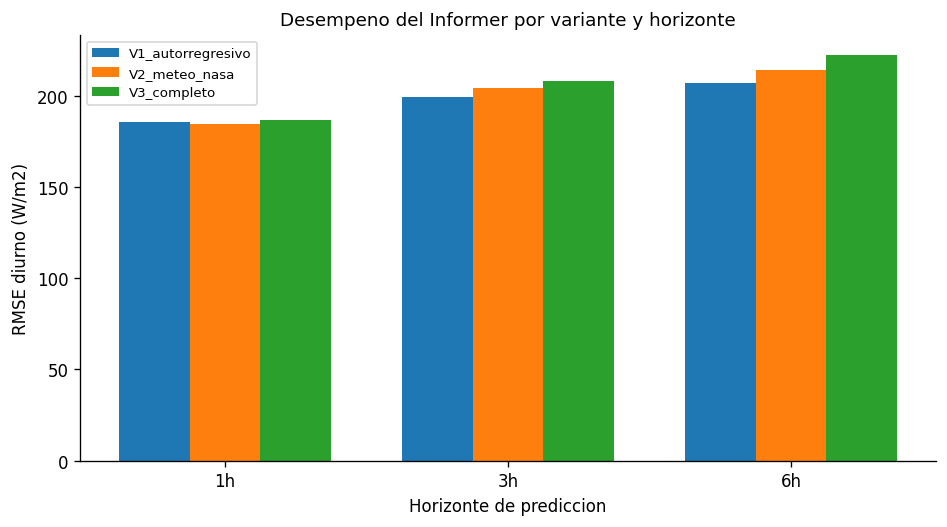

Figura guardada: figuras/rmse_por_variante.png


In [13]:
# 16. Figura 1: RMSE diurno por variante y horizonte
def _val(v, h, col):
    sub = df_met[(df_met.variante == v) & (df_met.horizonte == h)]
    return sub[col].values[0] if len(sub) else np.nan

horizontes = list(PRED_LENS.keys())
variantes  = list(GRUPOS_VARIABLES.keys())
x, w = np.arange(len(horizontes)), 0.25
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, v in enumerate(variantes):
    vals = [_val(v, h, 'RMSE_diurno') for h in horizontes]
    ax.bar(x + (i - 1) * w, vals, w, label=v)
ax.set_xticks(x); ax.set_xticklabels(horizontes)
ax.set_xlabel('Horizonte de prediccion'); ax.set_ylabel('RMSE diurno (W/m2)')
ax.set_title('Desempeno del Informer por variante y horizonte')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'rmse_por_variante.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/rmse_por_variante.png')

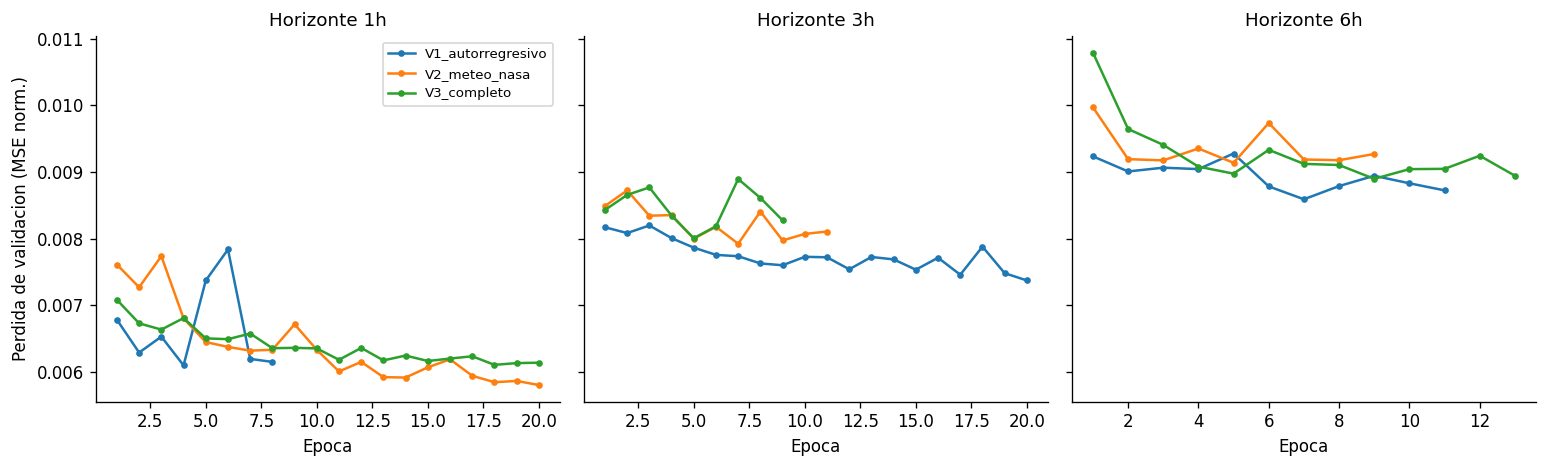

Figura guardada: figuras/curvas_aprendizaje.png


In [14]:
# 17. Figura 2: curvas de aprendizaje
with open(os.path.join(RUTA_RES, f'historias_{MODO}.pkl'), 'rb') as f:
    historias = pickle.load(f)

fig, axes = plt.subplots(1, len(PRED_LENS), figsize=(13, 4), sharey=True)
for ax, h in zip(np.atleast_1d(axes), PRED_LENS):
    hubo = False
    for v in GRUPOS_VARIABLES:
        hist = historias.get(f'{v}__{h}')
        if hist:
            ax.plot(range(1, len(hist['val_loss']) + 1), hist['val_loss'], marker='o', ms=3, label=v)
            hubo = True
    ax.set_title(f'Horizonte {h}'); ax.set_xlabel('Epoca')
    if not hubo:
        ax.text(0.5, 0.5, 'Sin historia\n(modelos cargados)', ha='center', va='center', transform=ax.transAxes)
np.atleast_1d(axes)[0].set_ylabel('Perdida de validacion (MSE norm.)')
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'curvas_aprendizaje.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/curvas_aprendizaje.png')

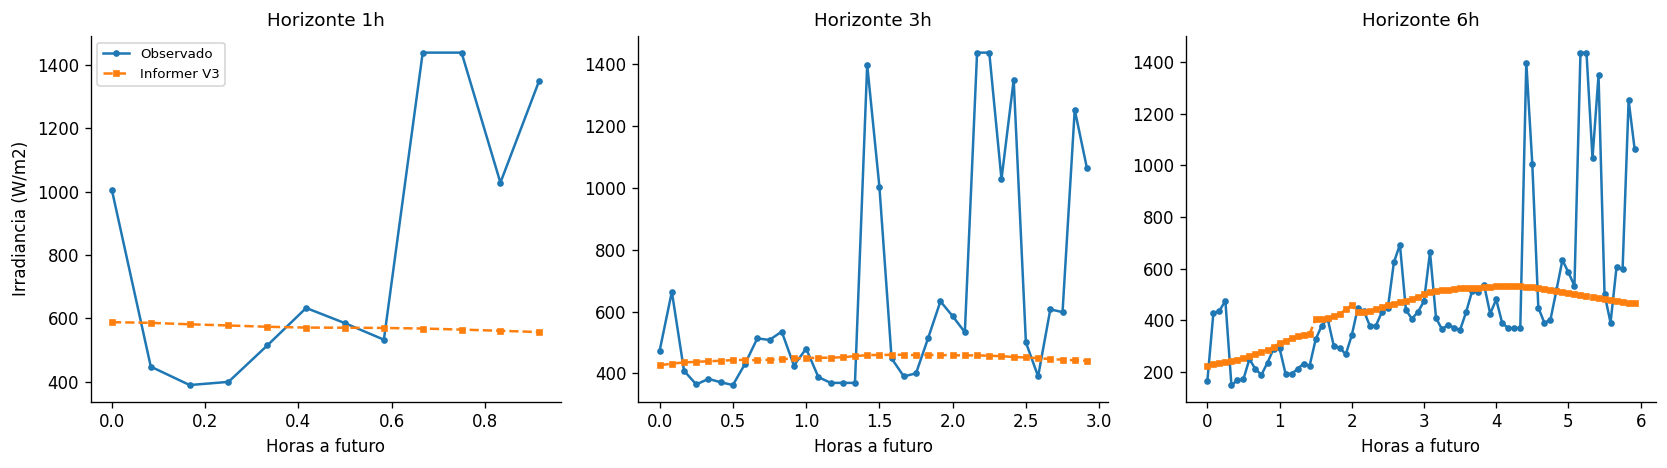

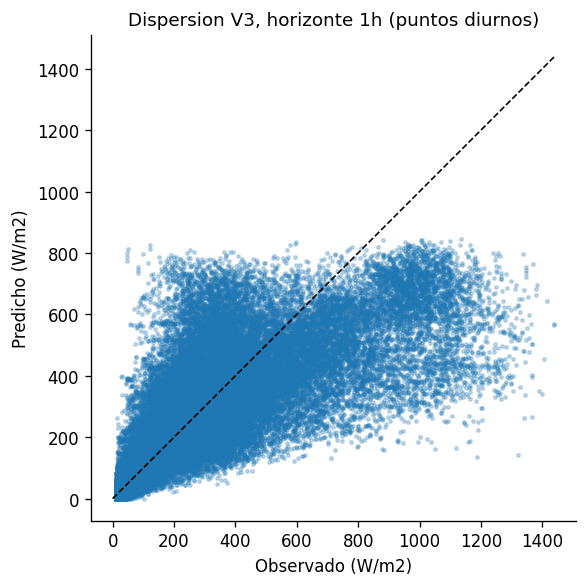

Figuras guardadas: figuras/prediccion_vs_observacion.png, figuras/dispersion_v3.png


In [15]:
# 18. Figuras 3 y 4: prediccion frente a observacion y dispersion (variante V3)
# Figura 3: una ventana diurna representativa por horizonte
fig, axes = plt.subplots(1, len(ejemplos), figsize=(14, 4))
for ax, h in zip(np.atleast_1d(axes), ejemplos):
    t_w, p_w = ejemplos[h]
    idx   = int(np.argmax(t_w.max(axis=1)))           # ventana con mayor irradiancia
    horas = np.arange(t_w.shape[1]) * 5 / 60.0
    ax.plot(horas, t_w[idx], 'o-', ms=3, label='Observado')
    ax.plot(horas, np.clip(p_w[idx], 0, None), 's--', ms=3, label='Informer V3')
    ax.set_title(f'Horizonte {h}'); ax.set_xlabel('Horas a futuro')
np.atleast_1d(axes)[0].set_ylabel('Irradiancia (W/m2)')
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'prediccion_vs_observacion.png'), dpi=150, bbox_inches='tight')
plt.show()

# Figura 4: dispersion predicho-observado (puntos diurnos, horizonte mas corto)
h0 = list(ejemplos.keys())[0]
t_w, p_w = ejemplos[h0]
m = t_w.ravel() > 10
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(t_w.ravel()[m], np.clip(p_w.ravel(), 0, None)[m], s=4, alpha=0.25)
lim = float(max(t_w.max(), p_w.max()))
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Observado (W/m2)'); ax.set_ylabel('Predicho (W/m2)')
ax.set_title(f'Dispersion V3, horizonte {h0} (puntos diurnos)')
plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'dispersion_v3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figuras guardadas: figuras/prediccion_vs_observacion.png, figuras/dispersion_v3.png')

## Resumen y entrega para el documento

Al ejecutar este notebook se obtienen los insumos de la Actividad 3 para que Juan redacte la seccion de Resultados:

- `resultados/metricas_variantes.csv` — tabla de MAE, RMSE, R2 (global y diurno), sMAPE diurno y *skill* frente a persistencia, por variante y horizonte.
- `figuras/rmse_por_variante.png` — comparacion central entre V1, V2 y V3.
- `figuras/curvas_aprendizaje.png` — evidencia de entrenamiento y validacion.
- `figuras/prediccion_vs_observacion.png` y `figuras/dispersion_v3.png` — desempeno cualitativo del modelo.
- `modelos/informer_*_{MODO}.pt` — pesos entrenados, reproducibles.

**Lectura sugerida para el documento:** la comparacion V1 -> V2 -> V3 cuantifica el aporte de NASA POWER (la diferencia V2 -> V3 aisla el valor de la irradiancia satelital, en linea con Taha et al., 2025); el *skill* positivo frente a persistencia justifica el uso del modelo; y el aumento del error de 1 h a 6 h documenta el limite de horizonte util.

**Recomendacion:** ejecutar primero en `MODO = 'piloto'` para validar el flujo; luego `MODO = 'completo'` para la corrida definitiva. Recordar que `hp_best.pkl` debe provenir de la corrida completa del Notebook 05.